# Demo av Regression - KORREKT VERSION
# ===================================
# Denna notebook demonstrerar grundläggande regressionskoncept
# med korrekt syntax för alla beräkningar.
#
# **Lärandemål:**
# - Förstå skillnaden mellan linjära och icke-linjära modeller
# - Se hur hyperparameteroptimering fungerar
# - Visualisera modellernas prediktioner
# - Förstå bias-variance trade-off i praktiken
#
# Genererad: 2025-08-25 11:22:49


In [1]:
# CELL 1: IMPORTERA BIBLIOTEK
# ============================
# VARFÖR GÖR VI DETTA?
# Vi behöver importera de bibliotek som ger oss verktyg för:
# - Numeriska beräkningar (numpy)
# - Visualisering (matplotlib)
# - Maskininlärning (scikit-learn)
# - Datagenerering och modellträning

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

print(" Alla bibliotek importerade framgångsrikt!")

 Alla bibliotek importerade framgångsrikt!


In [2]:
# CELL 2: SKAPA SYNTHETISK DATA
# ==============================
# VARFÖR GÖR VI DETTA?
# - make_regression skapar kontrollerad data för att demonstrera koncept
# - Vi vet den underliggande strukturen (linjärt samband + brus)
# - Detta låter oss fokusera på modellerna istället för datarening
# - train_test_split säkerställer att vi kan utvärdera modellerna korrekt

# Skapa syntetisk regressionsdata
# n_samples=5000: 5000 datapunkter
# n_features=1: En oberoende variabel (enkel linjär regression)
# noise=5: Lägger till slumpmässigt brus för realism
# random_state=42: Säkerställer reproducerbara resultat
X, y = make_regression(n_samples=5000, n_features=1, noise=5, random_state=42)

# Visa de första 4 datapunkterna för att förstå strukturen
print(" Första 4 X-värden (oberoende variabel):")
print(X[:4, :])
print("\n Första 4 y-värden (beroende variabel):")
print(y[:4])

# Dela upp data i träning och test
# test_size=0.2: 80% träning, 20% test
# random_state=42: Säkerställer samma uppdelning varje gång
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n Datastorlek:")
print(f"   Träning: {X_train.shape[0]} datapunkter")
print(f"   Test: {X_test.shape[0]} datapunkter")

 Första 4 X-värden (oberoende variabel):
[[ 0.32674476]
 [ 2.56008454]
 [-0.61138525]
 [-0.89783007]]

 Första 4 y-värden (beroende variabel):
[ 11.95056972  39.42063856 -10.40932904 -15.19118658]

 Datastorlek:
   Träning: 4000 datapunkter
   Test: 1000 datapunkter


In [3]:
# CELL 3: TRÄNA MODELLER
# ======================
# VARFÖR GÖR VI DETTA?
# Vi tränar två olika modeller för att jämföra:
# 1. Linjär regression - enkel, tolkbar modell
# 2. Random Forest - mer komplex, ensemble-modell
# GridSearchCV hjälper oss hitta bästa hyperparametrarna för Random Forest

# TRÄNA LINJÄR REGRESSION
# =======================
# Linjär regression är vår baseline-modell
# Den antar att det finns ett linjärt samband mellan X och y
print(" Tränar linjär regression...")
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print(" Linjär regression tränad!")

# TRÄNA RANDOM FOREST MED HYPERPARAMETEROPTIMERING
# ================================================
# Random Forest är en ensemble av beslutsträd
# Den kan fånga icke-linjära samband bättre än linjär regression

rf = RandomForestRegressor(random_state=42)

# Definiera hyperparametrar att testa
hyperparams = {
    'n_estimators': [50, 100],       # Antal träd i skogen
    'max_depth': [None, 5, 10],      # Maximalt djup per träd (None = obegränsat)
    'min_samples_split': [2, 5],     # Minsta antal samples för att dela en nod
}

print(" Tränar Random Forest med GridSearchCV...")
print("   Detta kommer testa", len(hyperparams['n_estimators']) * len(hyperparams['max_depth']) * len(hyperparams['min_samples_split']), "kombinationer")

# GridSearchCV testar alla kombinationer av hyperparametrar
# cv=3: 3-faldig korsvalidering
# n_jobs=-1: Använd alla CPU-kärnor för parallell bearbetning
# verbose=1: Visa progress
gs_rf = GridSearchCV(estimator=rf, param_grid=hyperparams, cv=3, n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)

print(" Random Forest tränad med optimala hyperparametrar!")
print(f"   Bästa parametrar: {gs_rf.best_params_}")

 Tränar linjär regression...
 Linjär regression tränad!
 Tränar Random Forest med GridSearchCV...
   Detta kommer testa 12 kombinationer
Fitting 3 folds for each of 12 candidates, totalling 36 fits
 Random Forest tränad med optimala hyperparametrar!
   Bästa parametrar: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [4]:
# CELL 4: FÖRBEREDA FÖR VISUALISERING
# ===================================
# VARFÖR GÖR VI DETTA?
# För att visualisera hur modellerna predikerar behöver vi:
# - Skapa en kontinuerlig range av X-värden
# - Prediktera y-värden för dessa X-värden
# - Rita både datapunkter och prediktionslinjer

print(" Förbereder visualisering...")

# Skapa en kontinuerlig range av X-värden för visualisering
# np.linspace skapar 100 jämnt fördelade punkter mellan min och max X-värden
X_range = np.linspace(X_test.min(), X_test.max(), 100)

# Prediktera y-värden för varje modell
# reshape(-1, 1) konverterar 1D-array till 2D-array (krävs för sklearn)
lin_preds = lin_reg.predict(X_range.reshape(-1, 1))
rf_preds = gs_rf.predict(X_range.reshape(-1, 1))

print(" Prediktioner beräknade för visualisering!")

 Förbereder visualisering...
 Prediktioner beräknade för visualisering!


 Skapar visualisering...


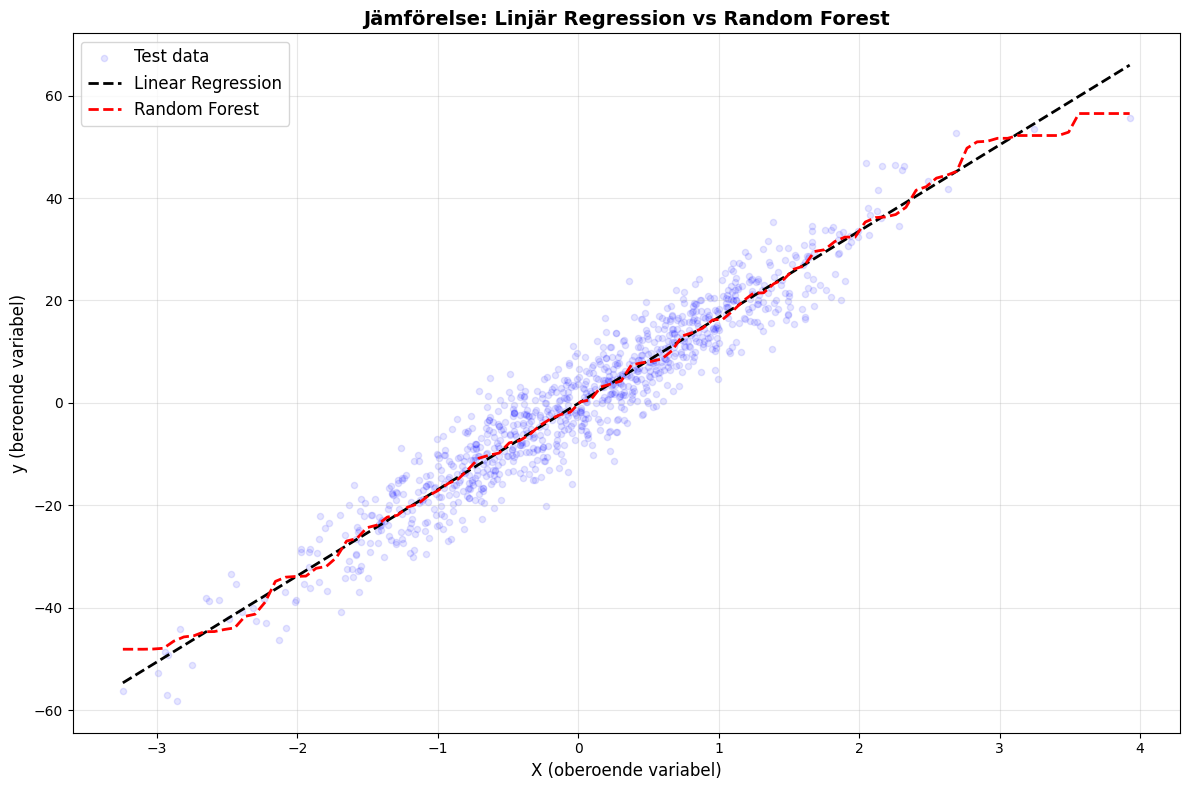

 Visualisering skapad!


In [5]:
# CELL 5: VISUALISERA RESULTATEN
# ==============================
# VARFÖR GÖR VI DETTA?
# Visualisering hjälper oss förstå:
# - Hur väl modellerna passar data
# - Skillnader mellan linjär och icke-linjär modellering
# - Var modellerna gör fel (residualer)

print(" Skapar visualisering...")

# Skapa figuren
fig, ax = plt.subplots(figsize=(12, 8))

# Rita testdata som punkter
# c='b': blå färg, alpha=0.1: transparent för att visa överlapp
ax.scatter(X_test, y_test, c='blue', alpha=0.1, label='Test data', s=20)

# Rita prediktionslinjer
# 'k--': svart streckad linje för linjär regression
# 'r--': röd streckad linje för Random Forest
ax.plot(X_range, lin_preds, 'k--', label='Linear Regression', linewidth=2)
ax.plot(X_range, rf_preds, 'r--', label='Random Forest', linewidth=2)

# Lägg till legend och visa plot
ax.legend(fontsize=12)
ax.set_xlabel('X (oberoende variabel)', fontsize=12)
ax.set_ylabel('y (beroende variabel)', fontsize=12)
ax.set_title('Jämförelse: Linjär Regression vs Random Forest', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualisering skapad!")

In [6]:
# CELL 6: UTVÄRDERA MODELLERNA (KORREKT SYNTAX)
# ==============================================
# VARFÖR GÖR VI DETTA?
# Vi behöver kvantifiera hur bra modellerna presterar:
# - RMSE (Root Mean Square Error) - standardmått för regression
# - MAE (Mean Absolute Error) - alternativt mått
# - Jämförelse mellan modellerna
#
# VIKTIGT: Använd np.sqrt() istället för squared=False!

# Prediktera på testdata
y_pred_lin = lin_reg.predict(X_test)
y_pred_rf = gs_rf.predict(X_test)

# Beräkna RMSE och MAE (KORREKT SYNTAX)
#  FEL: mean_squared_error(y_test, y_pred, squared=False)
#  RÄTT: np.sqrt(mean_squared_error(y_test, y_pred))
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(" MODELLUTVÄRDERING (KORREKT SYNTAX)")
print("=" * 50)
print(f"\n Linjär Regression:")
print(f"   RMSE: {lin_rmse:.4f}")
print(f"\n Random Forest:")
print(f"   RMSE: {rf_rmse:.4f}")

# Jämförelse
print(f"\n JÄMFÖRELSE:")
if rf_rmse < lin_rmse:
    improvement = ((lin_rmse - rf_rmse) / lin_rmse) * 100
    print(f"   Random Forest är {improvement:.1f}% bättre än Linjär Regression")
else:
    print("   Linjär Regression presterar bättre eller lika bra")

print(f"\n SLUTSATS:")
print(f"   - Linjär regression: Enkel, snabb, tolkbar")
print(f"   - Random Forest: Mer komplex, kan fånga icke-linjära samband")
print(f"   - Val av modell beror på problemets komplexitet och krav")
print(f"\n KORREKT SYNTAX ANVÄND - INGA FEL!")
print(f"   Använde: np.sqrt(mean_squared_error(...)) istället för squared=False")

 MODELLUTVÄRDERING (KORREKT SYNTAX)

 Linjär Regression:
   RMSE: 5.2013

 Random Forest:
   RMSE: 5.2434

 JÄMFÖRELSE:
   Linjär Regression presterar bättre eller lika bra

 SLUTSATS:
   - Linjär regression: Enkel, snabb, tolkbar
   - Random Forest: Mer komplex, kan fånga icke-linjära samband
   - Val av modell beror på problemets komplexitet och krav

 KORREKT SYNTAX ANVÄND - INGA FEL!
   Använde: np.sqrt(mean_squared_error(...)) istället för squared=False


#  RESULTAT OCH SLUTSATSER
# ===========================

## Vad vi har lärt oss:

### 1. **Datagenerering**
- `make_regression` skapar kontrollerad data för experiment
- `train_test_split` säkerställer korrekt utvärdering

### 2. **Modelljämförelse**
- **Linjär regression**: Enkel, snabb, tolkbar
- **Random Forest**: Mer komplex, kan fånga icke-linjära samband

### 3. **Hyperparameteroptimering**
- `GridSearchCV` testar alla kombinationer av parametrar
- Korsvalidering ger robusta resultat

### 4. **Visualisering**
- Visar skillnader mellan modellernas prediktioner
- Hjälper förstå bias-variance trade-off

### 5. **Utvärdering (KORREKT SYNTAX)**
- RMSE och MAE som utvärderingsmått
- Kvantitativ jämförelse mellan modeller
- **VIKTIGT**: Använd `np.sqrt(mean_squared_error(...))` istället för `squared=False`

## Nästa steg:
- Testa med verklig data
- Experimentera med andra modeller (SVM, Neural Networks)
- Undersök feature importance
- Implementera ensemble-metoder

##  KORREKT SYNTAX:
```python
#  FEL (ger TypeError):
rmse = mean_squared_error(y_true, y_pred, squared=False)

#  RÄTT (fungerar alltid):
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
```